# **Correspondence to metabolomic data**

In [1]:
import harreman
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import muon as mu
import seaborn as sns
import matplotlib.pyplot as plt
import mplscience
from scipy.stats import hypergeom, zscore, wilcoxon, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from plotnine import *
import warnings
warnings.filterwarnings("ignore")

BASE_PATH = "/home/projects/nyosef/oier/Harreman_files/Revision/Visium_RCC"
ADATA_PATH = f"{BASE_PATH}/h5ads"
DATA_PATH = f"{BASE_PATH}/data"
PLOTS_PATH = f"{BASE_PATH}/plots"

/home/projects/nyosef/oier/mambaforge/envs/harreman_pip-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/projects/nyosef/oier/mambaforge/envs/harreman_pip-env/lib/python3.12/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
harreman_adata = sc.read_h5ad(f'{ADATA_PATH}/Visium_RCC_Harreman_unrolled.h5ad')

In [3]:
exchange_metabolite_sets = {
    'ATP_related': {
        'Harreman': ['ATP', 'ADP', 'Adenosine', 'Cyclic AMP'],
        'scCellFie': ['ATP generation from glucose (hypoxic conditions) - glycolysis',
                      'ATP regeneration from glucose (normoxic conditions) - glycolysis + krebs cycle',
                      'Oxidative phosphorylation via NADH-coenzyme Q oxidoreductase (COMPLEX I)',
                      'Oxidative phosphorylation via succinate-coenzyme Q oxidoreductase (COMPLEX II)',
                      'AMP salvage from adenine',
                      'GMP salvage from guanine',
                      'IMP salvage from hypoxanthine',
                      'Inosine monophosphate synthesis (IMP)',
                      'Guanosine triphosphate synthesis (GTP)',
                      'Cytidine triphosphate synthesis (CTP)',],
        'MSI metabolites': ["Adenosine monophosphate;\n2'-Deoxyguanosine 5'-monophosphate;\n3'-AMP;\nAdenosine 2'-phosphate",
                            '2-Chloroadenosine;\n8-Chloroadenosine',
                            "5'-N-Methylcarboxamidoadenosine",
                            'Adenylsuccinic acid',
                            "Uridine 5'-monophosphate;\nPseudouridine 5'-phosphate;\nUridine 2'-phosphate",
                            'Uridine;\nPseudouridine',
                            'Uracil;\n4-Carboxypyrazole',
                            'Hypoxanthine',
                            'Xanthine;\nOxypurinol;\n6,8-Dihydroxypurine',
                            'Guanosine monophosphate;\n8-Oxo-dGMP',],
    },
    'Creatine_Carnitine_related': {
        'Harreman': ['Creatine', 'Acetyl-L-Carnitine', 'L-Carnitine'],
        'scCellFie': ['Synthesis of creatine from arginine',],
        'MSI metabolites': ['Creatine;\nBeta-Guanidinopropionic acid',
                            'Creatinine aspartate',
                            'Azelaic acid;\nNonate;\n2,4-Dimethylpimelic acid;\n3-Methylsuberic acid',
                            'Undecanedioic acid;\nButyl butyryllactate',
                            'Octadecanedioic acid;\n9,10-DHOME;\n12,13-DHOME;\nDibutyl decanedioate',
                            'Tridec-8-enedioylcarnitine;\nTridec-10-enedioylcarnitine;\nTridec-11-enedioylcarnitine;\n(6E)-Tridec-6-enedioylcarnitine;\n(9E)-Tridec-9-enedioylcarnitine',
                            '3-hydroxyundecanoyl carnitine',
                            '4-Hydroxytetradecanedioylcarnitine;\n6-Hydroxytetradecanedioylcarnitine;\n7-Hydroxytetradecanedioylcarnitine;\n5-Hydroxytetradecanedioylcarnitine;\n3-hydroxytetradecanedioylcarnitine'],
    },
    'GABA_related': {
        'Harreman': ['GABA', 'L-Glutamate', 'beta-Alanine'],
        'scCellFie': ['Synthesis of GABA', 'Conversion of GABA into succinate', 'beta-Alanine synthesis', 'beta-Alanine degradation', 'Beta-alanine to 3-oxopropanoate'],
        'MSI metabolites': ['Dimethylglycine;\ngamma-Aminobutyric acid;\nL-alpha-Aminobutyric acid;\nD-alpha-Aminobutyric acid;\n2-Aminoisobutyric acid;\n(S)-beta-Aminoisobutyric acid;\n(R)-beta-Aminoisobutyric acid;\n3-Aminoisobutanoic acid;\n3-Aminobutanoic acid;\nN-Ethylglycine',
                            '3-Hydroxybutyric acid;\n(S)-3-Hydroxybutyric acid;\n4-Hydroxybutyric acid;\nEthoxyacetic acid',
                            'Taurine',
                            'L-Glutamine;\nUreidoisobutyric acid;\nD-Glutamine',],
    },
    'TCA_related': {
        'Harreman': ['Citrate', 'Succinate', 'Fumarate', 'Malate'],
        'scCellFie': ['Krebs cycle - NADH generation', 'Krebs cycle - oxidative decarboxylation of pyruvate',
                      'Malate to pyruvate conversion', 'Glutaminolysis (glutamine to lactate)'],
        'MSI metabolites': ['cis-Aconitic acid;\ntrans-Aconitic acid;\nDehydroascorbic acid',
                            'Stearyl citrate',
                            '3-Hydroxybutyric acid;\n(S)-3-Hydroxybutyric acid;\n4-Hydroxybutyric acid;\nEthoxyacetic acid',
                            'Hydroxypropionic acid;\nGlyceraldehyde;\nDihydroxyacetone;\nMethoxyacetic acid',],
    },
    'FA_related': {
        'Harreman': ['Fatty acid', 'beta-D-hydroxybutyrate', 'Acetate'],
        'scCellFie': ['Palmitate degradation', 'Linoleate degradation', 'Palmitolate degradation', 'Linolenate degradation', 'Elaidate degradation', 'cis-vaccenic acid degradation',
                      'Arachidonate degradation', 'gamma-Linolenate degradation', '(R)-3-Hydroxybutanoate synthesis'],
        'MSI metabolites': ['FA(14:0);\n2,6,10-Trimethylundecanoic acid;\n12-Methyltridecanoic acid;\n10-Methyltridecanoic acid',
                            'FA(16:0);\nTrimethyltridecanoic acid;\nIsopalmitic acid;\nButyl dodecanoate;\nDodecyl butyrate;\nHexyl decanoate;\nOctyl octanoate;\nEthyl tetradecanoate;\nDodecyl 2-methylpropanoate',
                            'FA(18:2);\nBovinic acid;\n(9E,11E)-Octadecadienoic acid;\nLinoelaidic acid;\nMangiferic acid;\n5-Octadecynoic acid;\nC18:2;\nOctadecadienoate',
                            'FA(18:3);\nCalendic acid;\nPunicic acid;\nLinolenelaidic acid',
                            'FA(20:3);\n5,8,11-Eicosatrienoic acid;\nSciadonic acid;\nSagittariol',
                            'FA(20:4);\nCis-8,11,14,17-Eicosatetraenoic acid',
                            'FA(20:5);\nRetinyl ester;\n8,15-Isopimaradien-18-oic acid;\nIsopimaric acid;\n8,13-Abietadien-18-oic acid',
                            'FA(22:6);\nNeogrifolin;\nGrifolin',
                            '5,6-Epoxy-8,11,14-eicosatrienoic acid;\n14R,15S-EpETrE;\n15-HETE;\n14,15-Epoxy-5,8,11-eicosatrienoic acid;\n11,12-Epoxyeicosatrienoic acid;\n8-HETE;\n16(R)-HETE;\n11(R)-HETE;\n20-Hydroxyeicosatetraenoic acid;\nFA(20:4(5Z,8Z,10E,12-OH,14Z));\n18-Hydroxyarachidonic acid;\n9-HETE;\nFA(20:4(5-OH,6E,8Z,11Z,14Z));\n19(S)-HETE;\n10-HETE;\n13-HETE;\n17-HETE;\n12 Hydroxy arachidonic acid;\n12S-hydroxy-5E,8Z,10Z,14Z-eicosatetraenoic acid;\n15R-hydroxy-5Z,8Z,11Z,13E-eicosatetraenoic acid;\n18-Hydroxy-5Z,8Z,11Z,14Z-eicosatetraenoic acid;\n7-HETE;\n8-hydroxy-5Z,9E,11Z,14Z-eicosatetraenoic acid',
                            '8(R)-Hydroperoxylinoleic acid;\n9(S)-HPODE;\n12,13-DiHODE;\n15,16-DiHODE;\n9,10-DiHODE;\n(�)-(E)-13-Hydroxy-10-oxo-11-octadecenoic acid;\n(10E,12Z)-(9S)-9-Hydroperoxyoctadeca-10,12-dienoic acid',
                            '9,12,13-TriHOME;\n9,10,13-TriHOME;\n5,8,12-Trihydroxy-9-octadecenoic acid;\n(9S,10E,12S,13S)-9,12,13-Trihydroxy-10-octadecenoic acid',],
    }
}

In [4]:
harreman_adata.uns['metabolites']

array(['(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3-yl-b-D-Glucopyranosiduronic acid',
       '17a-Ethynylestradiol', '1b,3a,12a-Trihydroxy-5b-cholanoic acid',
       '2-Hydroxychlorpropamide', '25-Hydroxycholesterol',
       "3',4'-Dihydrodiol", '3-Sulfodeoxycholic acid',
       '3alpha,7alpha-Dihydroxycoprostanic acid',
       '3b-Hydroxy-5-cholenoic acid', "4'-Hydroxydiclofenac",
       '4-Hydroxycyclophosphamide', '4-ene-Valproic acid',
       "5'-Hydroxypiroxicam", '5-Hydroxyomeprazole',
       '5-Methyltetrahydrofolic acid', '8-Hydroxycarvedilol', 'ADGRA',
       'ADGRE', 'ADGRG', 'ADGRL', 'ADM', 'ADP', 'AGRN', 'ANGPT', 'ANGPTL',
       'ANNEXIN', 'APELIN', 'ATP', 'Acetate', 'Acetyl-L-Carnitine',
       'Adenine', 'Adenosine', 'Adenosine diphosphate ribose',
       'Adenosine triphosphate', 'Adenosylcobalamin', 'Adrenaline',
       'Amiloride-sensitive sodium transport', 'Anion exchange', 'ApoE',
       'Arachidonic acid', 'BMP', 'BTLA', 'Barium', 'Betaine',
       'Bile acid'

In [4]:
sccellfie_adata = sc.read_h5ad(f'{ADATA_PATH}/Visium_RCC_scCellFie.h5ad')
sccellfie_adata.metabolic_tasks = sc.read_h5ad(f'{ADATA_PATH}/Visium_RCC_scCellFie_metabolic_tasks.h5ad')
sccellfie_adata.reactions = sc.read_h5ad(f'{ADATA_PATH}/Visium_RCC_scCellFie_reactions.h5ad')

In [6]:
sccellfie_adata.metabolic_tasks.var_names.tolist()

['(R)-3-Hydroxybutanoate synthesis',
 "3'-Phospho-5'-adenylyl sulfate synthesis",
 'AMP salvage from adenine',
 'ATP generation from glucose (hypoxic conditions) - glycolysis',
 'ATP regeneration from glucose (normoxic conditions) - glycolysis + krebs cycle',
 'Acetoacetate synthesis',
 'Alanine degradation',
 'Alanine synthesis',
 'Arachidonate degradation',
 'Arachidonate synthesis',
 'Arginine degradation',
 'Arginine synthesis',
 'Asparagine degradation',
 'Asparagine synthesis',
 'Aspartate degradation',
 'Aspartate synthesis',
 'Beta-alanine to 3-oxopropanoate',
 'Biosynthesis of Tn_antigen (Glycoprotein N-acetyl-D-galactosamine)',
 'Biosynthesis of core2 (beta-D-Galactosyl-1,3-(N-acetyl-beta-D-glucosaminyl-1,6)-N-acetyl-D-galactosaminyl-R)',
 'Biosynthesis of core4 (N-Acetyl-beta-D-glucosaminyl-1,6-(N-acetyl-beta-D-glucosaminyl-1,3)-N-acetyl-D-galactosaminyl-R)',
 'Branching (N-acetylglucosaminyltransferases)',
 'CMP-N-acetylneuraminate synthesis',
 'Calnexin/calreticulin cycle'

## Analysis

In [5]:
# msi_neg = sc.read_h5ad(os.path.join(f"{ADATA_PATH}/neg_msi.h5ad"))
msi_neg = sc.read_h5ad(os.path.join(f"{ADATA_PATH}/neg_msi_new.h5ad"))

In [6]:
# rna = sc.read_h5ad(os.path.join(f"{ADATA_PATH}/neg_rna.h5ad"))
rna = sc.read_h5ad(os.path.join(f"{ADATA_PATH}/neg_rna_new.h5ad"))

In [7]:
def compute_rna_msi_correlation(rna, msi, scores, sign='pos'):
    
    metabolite_names = msi.var_names.tolist()
    
    if sign not in ['pos', 'neg']:
        raise ValueError("The sign variable needs to be either 'pos' or 'neg'.")
    
    msi_key = f'msi_{sign}'
    msi_scores_rna = pd.DataFrame(rna.obsm[msi_key],
                                  index=rna.obs_names,
                                  columns=metabolite_names).loc[scores.index]
    
    results = []
    for sample, idx in rna.obs.loc[msi_scores_rna.index].groupby("sample").groups.items():

        msi_sample = msi_scores_rna.loc[idx]
        score_sample = scores.loc[idx]

        # standardize inside sample
        msi_c   = (msi_sample   - msi_sample.mean())   / msi_sample.std(ddof=1)
        score_c = (score_sample - score_sample.mean()) / score_sample.std(ddof=1)

        corr = pd.DataFrame(
            msi_c.T.values @ score_c.values / (len(msi_c) - 1),
            index=msi_c.columns,
            columns=score_c.columns,
        )
        corr_long = (
            corr.stack()
            .reset_index()
            .rename(columns={"level_0": "metabolite", "level_1": "exchange",
                              0: "correlation"})
        )
        corr_long["sample"] = sample
        results.append(corr_long)
 
    return pd.concat(results, ignore_index=True)

In [8]:
interacting_cell_scores_m = pd.DataFrame(harreman_adata.uns['interacting_cell_results']['np']['m']['cs'],
                                         index=harreman_adata.obs_names,
                                         columns=harreman_adata.uns['metabolites']).loc[rna.obs_names]

In [9]:
metabolic_tasks_scores = pd.DataFrame(sccellfie_adata.metabolic_tasks.X,
                                      index=sccellfie_adata.metabolic_tasks.obs_names,
                                      columns=sccellfie_adata.metabolic_tasks.var_names).loc[rna.obs_names]

In [10]:
harreman_metab_corr_neg = compute_rna_msi_correlation(rna, msi_neg, interacting_cell_scores_m, sign='neg')
sccellfie_metab_corr_neg = compute_rna_msi_correlation(rna, msi_neg, metabolic_tasks_scores, sign='neg')

In [11]:
metabolite_annotation = pd.read_excel(f"{DATA_PATH}/spatial_metabolites_annotation.xlsx", index_col=0)

In [12]:
metabolite_annotation = metabolite_annotation.dropna(subset='Metabolites')

In [13]:
metabolite_annotation['mz_orig'] = metabolite_annotation['mz'].copy()
metabolite_annotation['mz'] = metabolite_annotation['mz'].round(3)

In [14]:
msi_neg.var = (
    msi_neg.var
    .reset_index()
    .merge(metabolite_annotation, on="mz", how="left")
    .set_index("index")
)

In [15]:
msi_neg.var['metabolite'] = msi_neg.var_names

In [16]:
harreman_metab_corr_neg_metab_info = harreman_metab_corr_neg.merge(msi_neg.var, on="metabolite", how="left")
sccellfie_metab_corr_neg_metab_info = sccellfie_metab_corr_neg.merge(msi_neg.var, on="metabolite", how="left")

In [17]:
# Fill missing Metabolites label with raw metabolite id
for df in [harreman_metab_corr_neg_metab_info,
           sccellfie_metab_corr_neg_metab_info]:
    mask = df['Metabolites'].isna()
    df.loc[mask, 'Metabolites'] = df.loc[mask, 'metabolite']

In [18]:
sample_metadata = pd.read_excel(f"{DATA_PATH}/RCC_paper_sup_tables.xlsx", sheet_name=None, index_col=0)['Table S1']

In [19]:
sample_metadata.columns = sample_metadata.iloc[0]
sample_metadata = sample_metadata.iloc[1:]

In [20]:
# Add immune subtype annotation
harreman_metab_corr_neg_metab_info['immune_subtype'] = (
    harreman_metab_corr_neg_metab_info['sample']
    .map(lambda x: sample_metadata.loc[x, 'immune subtype']
         if x in sample_metadata.index else 'NAT'))
sccellfie_metab_corr_neg_metab_info['immune_subtype'] = (
    sccellfie_metab_corr_neg_metab_info['sample']
    .map(lambda x: sample_metadata.loc[x, 'immune subtype']
         if x in sample_metadata.index else 'NAT'))

In [32]:
# sample_order = ["R_med", "R_cor", "J38_T", "X98_T", "Z43_T", "Y7_T", "S15_T", "R114_T", "X49_T", "Y27_T", "Y12_T", "R51_T", "R29_T", "H46_T"]
sample_order = ["R_cor", "Z43_T", "Y7_T", "R114_T", "R51_T", "R29_T", "Y27_T", "J38_T", "S15_T", "Y12_T", "X49_T"]

#### Enrichment

In [22]:
def rank_enrichment(corr_series, matched):
    """
    Compute mean percentile rank of matched MSI metabolites.
    Duplicate metabolite names collapsed via mean() (conservative vs max).
    Percentile 1.0 = highest correlation, 0.0 = lowest.
    """
    corr_series = corr_series.groupby(level=0).mean().dropna()
    ranks       = corr_series.rank(ascending=False, method="average")
    percentiles = 1 - (ranks - 1) / (len(ranks) - 1)
    matched     = [m for m in matched if m in percentiles.index]
    matched_scores = percentiles.loc[matched]
    return matched_scores, matched_scores.mean()
 
 
def permutation_test(corr_series, matched, n_perm=10000, rng=None):
    """
    One-sided permutation test: is the mean percentile of matched metabolites
    higher than expected by chance?
    Duplicate metabolite names collapsed via mean() before ranking.
    """
    if rng is None:
        rng = np.random.default_rng()
 
    corr_series = corr_series.groupby(level=0).mean().dropna()
    ranks       = corr_series.rank(ascending=False, method="average")
    percentiles = 1 - (ranks - 1) / (len(ranks) - 1)
    matched     = [m for m in matched if m in percentiles.index]
 
    if len(matched) == 0:
        return np.nan, np.array([]), np.nan
 
    observed   = percentiles.loc[matched].mean()
    metabolites = percentiles.index.values
    k           = len(matched)
    perm        = np.array([
        percentiles.loc[rng.choice(metabolites, size=k, replace=False)].mean()
        for _ in range(n_perm)
    ])
    pval = np.mean(perm >= observed)
    return observed, perm, pval

In [23]:
def run_enrichment(metab_corr_info, metabolite_sets, method_name,
                   method_key, exchange_col='exchange', n_perm=10000):
    """
    Run rank enrichment + permutation test for every
    (exchange, sample, metabolite_set) triple.
 
    Parameters
    ----------
    metab_corr_info : pd.DataFrame  long-format correlation table
    metabolite_sets : dict          exchange_metabolite_sets
    method_name : str               label for output ('Harreman' or 'scCellFie')
    method_key : str                key in metabolite_sets dict
                                    ('Harreman' or 'scCellFie')
    exchange_col : str              column holding exchange/task name
    n_perm : int
 
    Returns
    -------
    results_df, individual_df
    """
    rng = np.random.default_rng(42)
    results, individual_scores = [], []
 
    for set_, metabolite_dict in metabolite_sets.items():
        if method_key not in metabolite_dict:
            continue
        exchanges     = metabolite_dict[method_key]
        related_metabs = metabolite_dict['MSI metabolites']
 
        for exchange in exchanges:
            for sample in metab_corr_info['sample'].unique():
                subset = metab_corr_info[
                    (metab_corr_info[exchange_col] == exchange) &
                    (metab_corr_info['sample'] == sample)
                ].copy()
 
                if subset.empty:
                    continue
 
                # Collapse duplicate Metabolite names via mean
                corr_series = (
                    subset[['Metabolites', 'correlation']]
                    .groupby('Metabolites')['correlation']
                    .mean()
                )
 
                scores, mean_score = rank_enrichment(corr_series, related_metabs)
                obs, perm, p = permutation_test(
                    corr_series, related_metabs, n_perm=n_perm, rng=rng)
 
                n_metabs = len(scores)
                results.append({
                    "sample":          sample,
                    "set":             set_,
                    "exchange":        exchange,
                    "score":           obs,
                    "mean_percentile": mean_score,
                    "pvalue":          p,
                    "n_metabs":        n_metabs,
                    "method":          method_name,
                })
                for metab, score in scores.items():
                    individual_scores.append({
                        "sample":    sample,
                        "exchange":  exchange,
                        "metabolite": metab,
                        "percentile": score,
                        "method":    method_name,
                    })
 
    results_df    = pd.DataFrame(results)
    individual_df = pd.DataFrame(individual_scores)
 
    if not results_df.empty:
        results_df["padj"] = multipletests(
            results_df["pvalue"].fillna(1), method="fdr_bh")[1]
        epsilon = 1e-6
        results_df["padj"]          = results_df["padj"].clip(lower=epsilon)
        results_df["min_log10_padj"] = -np.log10(results_df["padj"])
 
    return results_df, individual_df

In [24]:
print("Running Harreman enrichment...")
harreman_results_df, harreman_individual_df = run_enrichment(
    harreman_metab_corr_neg_metab_info,
    exchange_metabolite_sets,
    method_name='Harreman',
    method_key='Harreman',
)
 
print("Running scCellFie enrichment (metabolic tasks)...")
sccellfie_results_df, sccellfie_individual_df = run_enrichment(
    sccellfie_metab_corr_neg_metab_info,
    exchange_metabolite_sets,
    method_name='scCellFie',
    method_key='scCellFie',
    exchange_col='Task',
)

Running Harreman enrichment...
Running scCellFie enrichment (metabolic tasks)...


In [25]:
def weighted_mean_summary(results_df):
    """
    For each (sample, set, method), compute the weighted mean percentile
    across ALL exchanges in the set, weighted by n_metabs.
    Replaces the original top-3 selection.
    """
    def _wmean(g):
        w = g['n_metabs'].values.astype(float)
        v = g['mean_percentile'].values
        mask = (w > 0) & ~np.isnan(v)
        w, v = w[mask], v[mask]
        if w.sum() == 0:
            return pd.Series({'weighted_mean': np.nan, 'total_weight': 0,
                              'sem': np.nan, 'n_exchanges': 0})
        wm   = np.average(v, weights=w)
        n    = len(v)
        wsem = (np.sqrt(np.average((v - wm)**2, weights=w)) / np.sqrt(n)
                ) if n > 1 else 0.0
        return pd.Series({'weighted_mean': wm, 'total_weight': w.sum(),
                          'sem': wsem, 'n_exchanges': n})
 
    return (
        results_df.dropna(subset=['mean_percentile'])
        .groupby(['sample', 'set', 'method'])
        .apply(_wmean)
        .reset_index()
    )

In [26]:
harreman_summary = weighted_mean_summary(harreman_results_df)
sccellfie_summary = weighted_mean_summary(sccellfie_results_df)
summary_df = pd.concat([harreman_summary, sccellfie_summary], ignore_index=True)

In [33]:
# Categorical sample ordering
sample_ord = [s for s in sample_order if s in summary_df['sample'].unique()]
summary_df['sample'] = pd.Categorical(
    summary_df['sample'], categories=sample_ord, ordered=True)

In [34]:
# Individual scores for jitter (all exchanges)
indiv_plot_df = (
    pd.concat([harreman_results_df, sccellfie_results_df], ignore_index=True)
    [['sample', 'set', 'method', 'mean_percentile', 'n_metabs']]
    .dropna().copy()
)
indiv_plot_df['sample'] = pd.Categorical(
    indiv_plot_df['sample'], categories=sample_ord, ordered=True)

In [35]:
all_results_df = pd.concat([harreman_results_df, sccellfie_results_df],
                            ignore_index=True)
 
stat_rows = []
for set_ in all_results_df['set'].unique():
    h = (all_results_df[(all_results_df['set'] == set_) &
                        (all_results_df['method'] == 'Harreman')]
         ['mean_percentile'].dropna())
    s = (all_results_df[(all_results_df['set'] == set_) &
                        (all_results_df['method'] == 'scCellFie')]
         ['mean_percentile'].dropna())
    if len(h) == 0 or len(s) == 0:
        continue
    stat, p = mannwhitneyu(h, s, alternative='two-sided')
    stat_rows.append({
        'set':              set_,
        'U':                stat,
        'pvalue':           p,
        'harreman_median':  h.median(),
        'sccellfie_median': s.median(),
        'n_harreman':       len(h),
        'n_sccellfie':      len(s),
    })
 
mwu_summary = pd.DataFrame(stat_rows)
if not mwu_summary.empty:
    mwu_summary['padj'] = multipletests(
        mwu_summary['pvalue'], method='fdr_bh')[1]
    mwu_summary['sig'] = mwu_summary['padj'].apply(
        lambda p: '***' if p < 0.001 else (
            '**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))
 
print("\nMann-Whitney U summary (Harreman vs scCellFie metabolic tasks):")
print(mwu_summary.to_string(index=False, float_format="{:.4f}".format))


Mann-Whitney U summary (Harreman vs scCellFie metabolic tasks):
                       set         U  pvalue  harreman_median  sccellfie_median  n_harreman  n_sccellfie   padj sig
               ATP_related 2347.0000  0.7718           0.4973            0.5120          44          110 0.8389  ns
Creatine_Carnitine_related  173.5000  0.8389           0.6025            0.6071          33           11 0.8389  ns
              GABA_related  819.0000  0.5944           0.5197            0.5211          32           55 0.8389  ns
               TCA_related  535.0000  0.3523           0.4373            0.4739          28           44 0.8389  ns
                FA_related 1273.0000  0.1539           0.7190            0.7575          31           99 0.7694  ns


In [40]:
all_results_df = pd.concat([harreman_results_df, sccellfie_results_df],
                            ignore_index=True)

stat_rows = []
for sample in all_results_df['sample'].unique():
    for set_ in all_results_df['set'].unique():
        h = (all_results_df[(all_results_df['sample'] == sample) &
                            (all_results_df['set'] == set_) &
                            (all_results_df['method'] == 'Harreman')]
             ['mean_percentile'].dropna())
        s = (all_results_df[(all_results_df['sample'] == sample) &
                            (all_results_df['set'] == set_) &
                            (all_results_df['method'] == 'scCellFie')]
             ['mean_percentile'].dropna())
        if len(h) == 0 or len(s) == 0:
            continue
        stat, p = mannwhitneyu(h, s, alternative='two-sided')
        stat_rows.append({
            'sample':           sample,
            'set':              set_,
            'U':                stat,
            'pvalue':           p,
            'harreman_median':  h.median(),
            'sccellfie_median': s.median(),
            'n_harreman':       len(h),
            'n_sccellfie':      len(s),
        })

mwu_per_sample = pd.DataFrame(stat_rows)
if not mwu_per_sample.empty:
    mwu_per_sample['padj'] = multipletests(
        mwu_per_sample['pvalue'], method='fdr_bh')[1]
    mwu_per_sample['sig'] = mwu_per_sample['padj'].apply(
        lambda p: '***' if p < 0.001 else (
            '**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))

print("\nMann-Whitney U summary per sample and set:")
print(mwu_per_sample.to_string(index=False, float_format="{:.4f}".format))


Mann-Whitney U summary per sample and set:
sample                        set       U  pvalue  harreman_median  sccellfie_median  n_harreman  n_sccellfie   padj sig
 J38_T                ATP_related 20.0000  1.0000           0.5971            0.5618           4           10 1.0000  ns
 J38_T Creatine_Carnitine_related  1.0000  1.0000           0.4462            0.4634           3            1 1.0000  ns
 J38_T               GABA_related  0.0000  0.0357           0.7376            0.8470           3            5 0.2153  ns
 J38_T                TCA_related 16.0000  0.0265           0.6864            0.6484           4            4 0.2153  ns
 J38_T                 FA_related  9.0000  0.4818           0.6638            0.7048           3            9 0.8438  ns
 R29_T                ATP_related 29.0000  0.2283           0.6367            0.5546           4           10 0.7500  ns
 R29_T Creatine_Carnitine_related  3.0000  0.5000           0.6918            0.6689           3            1

In [39]:
# Combine results
all_results_df = pd.concat([harreman_results_df, sccellfie_results_df], ignore_index=True)

# Compute fraction of significant events per method, sample and set
sig_fraction = (
    all_results_df
    .groupby(['method', 'sample', 'set'])
    .apply(lambda g: pd.Series({
        'n_total': len(g),
        'n_sig': (g['padj'] < 0.05).sum(),
        'frac_sig': (g['padj'] < 0.05).mean()
    }))
    .reset_index()
)

# Summary across samples (mean fraction per method and set)
sig_fraction_summary = (
    sig_fraction
    .groupby(['method', 'set'])
    .agg(
        mean_frac_sig=('frac_sig', 'mean'),
        sem_frac_sig=('frac_sig', 'sem'),
        n_samples=('sample', 'count')
    )
    .reset_index()
)

print("Fraction of significant events per method and set:")
print(sig_fraction_summary.to_string(index=False, float_format="{:.3f}".format))

print("\nFraction of significant events per method, sample and set:")
print(sig_fraction.to_string(index=False, float_format="{:.3f}".format))

Fraction of significant events per method and set:
   method                        set  mean_frac_sig  sem_frac_sig  n_samples
 Harreman                ATP_related          0.000         0.000         11
 Harreman Creatine_Carnitine_related          0.000         0.000         11
 Harreman                 FA_related          0.439         0.119         11
 Harreman               GABA_related          0.000         0.000         11
 Harreman                TCA_related          0.000         0.000         10
scCellFie                ATP_related          0.045         0.025         11
scCellFie Creatine_Carnitine_related          0.000         0.000         11
scCellFie                 FA_related          0.909         0.070         11
scCellFie               GABA_related          0.255         0.118         11
scCellFie                TCA_related          0.000         0.000         11

Fraction of significant events per method, sample and set:
   method sample                        se

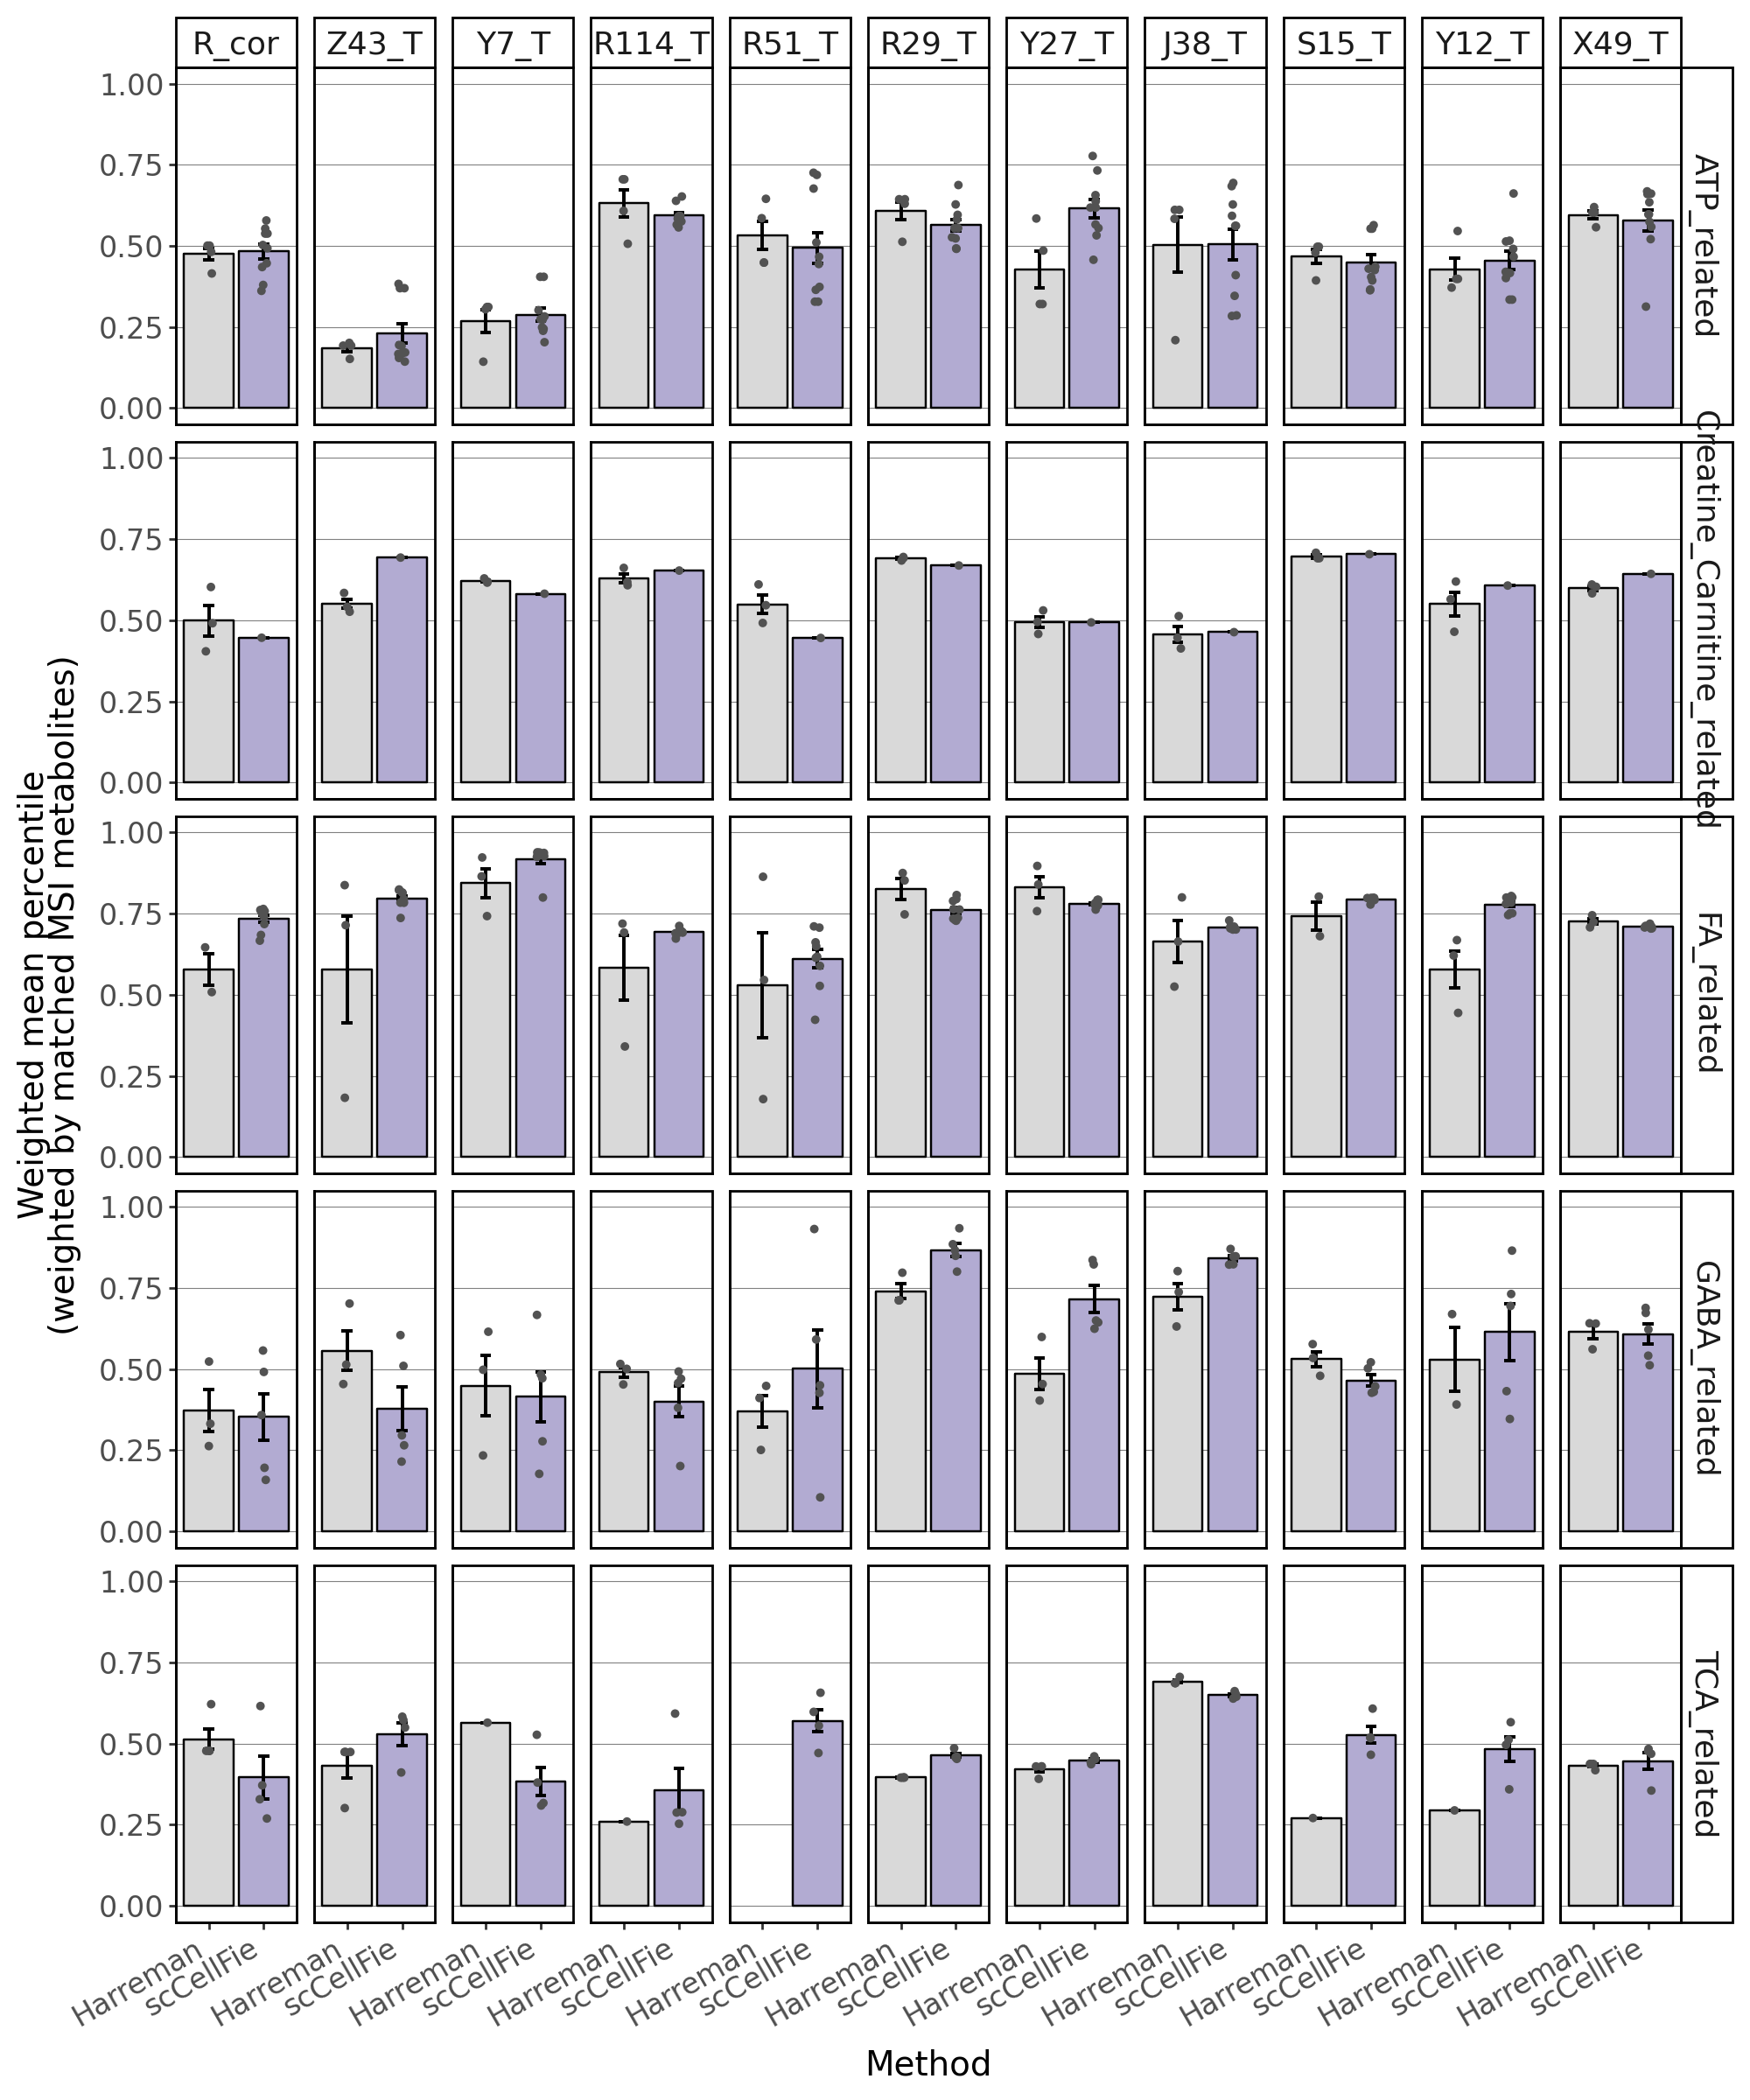

In [37]:
fig = (
    ggplot()
    + geom_col(
        data=summary_df,
        mapping=aes(x='method', y='weighted_mean', fill='method'),
        stat='identity', position=position_dodge(width=0.8), color='black',
    )
    + geom_errorbar(
        summary_df,
        aes(x='method', ymin='weighted_mean - sem', ymax='weighted_mean + sem',
            group='method'),
        position=position_dodge(width=0.8), width=0.2, size=0.8,
    )
    + geom_jitter(
        indiv_plot_df,
        aes(x='method', y='mean_percentile', color='method'),
        position=position_jitterdodge(jitter_width=0.15, dodge_width=0.8),
        size=1,
    )
    + facet_grid(rows='set', cols='sample', scales='free_y')
    + scale_fill_manual(values={'Harreman': '#D9D9D9', 'scCellFie': '#B2ABD2'})
    + scale_color_manual(values={'Harreman': '#525252', 'scCellFie': '#525252'})
    + scale_y_continuous(limits=(0, 1), breaks=[0, 0.25, 0.5, 0.75, 1])
    + theme_classic()
    + theme(
        panel_grid_major_y=element_line(color="grey", size=0.4),
        panel_grid_minor_y=element_blank(),
        plot_title=element_text(hjust=0.5, size=9),
        legend_position='none',
        strip_text=element_text(size=13),
        axis_title_x=element_text(size=14),
        axis_title_y=element_text(size=14),
        axis_text_x=element_text(size=12, rotation=30, hjust=1),
        axis_text_y=element_text(margin={"t": 0, "b": 0, "l": 0, "r": 2},
                                  size=12),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_border=element_rect(color='black'),
        panel_background=element_rect(colour="black", linewidth=1),
        figure_size=(10, 12),
    )
    + labs(x="Method",
           y="Weighted mean percentile\n(weighted by matched MSI metabolites)")
)
 
fig.show()
fig.save(os.path.join(PLOTS_PATH, 'msi_correspondence_metabolic_tasks.svg'))

In [38]:
os.path.join(PLOTS_PATH, 'msi_correspondence_metabolic_tasks.svg')

'/home/projects/nyosef/oier/Harreman_files/Revision/Visium_RCC/plots/msi_correspondence_metabolic_tasks.svg'